# StreetForward Stage4.3 — MultiSceneDatasetV3 + TrainSchedulerV4 集成测试

本 notebook 使用 `tools/train_minimal_streetforward_stage4_3_v4_common.py` 与训练脚本相同的数据集/调度器装配，验证：

- **单段**：`configs/minimal_streetforward_stage4_3_one_segment_v4.yaml` + `train_minimal_streetforward_stage4_3_one_segment_v4.py`
- **多场景**：`configs/minimal_streetforward_stage4_3_multi_scene_v4.yaml` + `train_minimal_streetforward_stage4_3_multi_scene_v4.py`（`train_scene_ids` 多场景、`traversal` 为 null，按 epoch 打乱 scene/segment）
- `datasets/dataset_preload_manager.py`：`parse_preload_cfg`
- 视角 overlap 调度：`docs/trainers/TrainScheduler_V4_Overlap_Pointcloud_TopK.md`（`scheduler_v4.overlap.mode`：`none` / `pointcloud_topk`）

**环境**：`conda` 环境 `drivestudio-new`；`PYTHONPATH` 指向仓库根目录。

**数据**：`initialize()` 需有效 `data.data_root`。

In [1]:
from __future__ import annotations

import os
import sys


def _resolve_repo_root() -> str:
    cwd = os.getcwd()
    if os.path.isfile(os.path.join(cwd, "datasets", "multi_scene_dataset_v3.py")):
        return cwd
    parent = os.path.dirname(cwd)
    if os.path.isfile(os.path.join(parent, "datasets", "multi_scene_dataset_v3.py")):
        return parent
    raise RuntimeError(
        "Cannot find repo root (expected datasets/multi_scene_dataset_v3.py). "
        "cd to the repository root or notebook/ subfolder, or set os.environ['DRIVESTUDIO_REPO']."
    )


REPO_ROOT = os.environ.get("DRIVESTUDIO_REPO") or _resolve_repo_root()
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.environ.setdefault("PYTHONPATH", REPO_ROOT)

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /root/drivestudio-coding


## 1. 配置文件路径

- 单段：`minimal_streetforward_stage4_3_one_segment_v4.yaml`
- 多场景：`minimal_streetforward_stage4_3_multi_scene_v4.yaml`（`data.train_scene_ids` 至少 2 个）

In [2]:
from omegaconf import OmegaConf

CONFIG_ONE_SEGMENT = os.path.join(REPO_ROOT, "configs", "minimal_streetforward_stage4_3_one_segment_v4.yaml")
CONFIG_MULTI_SCENE = os.path.join(REPO_ROOT, "configs", "minimal_streetforward_stage4_3_multi_scene_v4.yaml")

cfg_one = OmegaConf.load(CONFIG_ONE_SEGMENT)
cfg_multi = OmegaConf.load(CONFIG_MULTI_SCENE)

for name, c in [("one_segment", cfg_one), ("multi_scene", cfg_multi)]:
    if "model" not in c:
        raise ValueError(f"{name}: config must contain 'model'")
    if "training" not in c:
        c.training = {}

print("one_segment:", CONFIG_ONE_SEGMENT)
print("  train_scene_ids:", list(cfg_one.data.train_scene_ids))
print("multi_scene:", CONFIG_MULTI_SCENE)
print("  train_scene_ids:", list(cfg_multi.data.train_scene_ids))

one_segment: /root/drivestudio-coding/configs/minimal_streetforward_stage4_3_one_segment_v4.yaml
  train_scene_ids: [1]
multi_scene: /root/drivestudio-coding/configs/minimal_streetforward_stage4_3_multi_scene_v4.yaml
  train_scene_ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


## 2. 共享构建函数（与训练脚本一致）

`train_minimal_streetforward_stage4_3_v4_common.build_*`

In [3]:
import torch

from tools.train_minimal_streetforward_stage4_3_v4_common import (
    build_multi_scene_dataset_v3,
    build_train_scheduler_v4_from_cfg,
    parse_include_test_v4,
    resolve_fixed_scene_segment,
    validate_train_scene_for_fixed,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
device: cuda


## 4. 多场景（multi_scene）数据循环

要求：配置中**无** `one_segment`；`scheduler_v4.traversal.fixed_scene_id` / `fixed_segment_id` 为 null；`len(train_scene_ids) >= 2`。

下一格会**逐步打印**：scene/segment、raw 与 U 域进度、block 索引、`u_in_block`（block 内 update 进度）、`K_u_*`、`source_image_ref`、batch 形状，以及本步 `pop_events`（`segment_begin` / `reset_event` / **`overlap_select`**（仅 `scheduler_v4.overlap.mode=pointcloud_topk` 时） / `block_begin` / `block_end` / `segment_end` / `preload_hint`）。`block_begin` 在 pointcloud_topk 下可含 `overlap_mode`、`selected_target_scores`。可用 `PRINT_EVERY` 稀疏输出。

在最多 `MULTI_MAX_STEPS` 步内若 `get_current_info()["scene_id"]` 出现至少两个不同值则判定多场景切换正常。

In [4]:
if cfg_multi.get("one_segment") is not None:
    raise ValueError("multi_scene config must not define one_segment")
if len(list(cfg_multi.data.train_scene_ids)) < 2:
    raise ValueError("multi_scene config expects len(data.train_scene_ids) >= 2")
fs, fg = resolve_fixed_scene_segment(cfg_multi)
if fs is not None or fg is not None:
    raise ValueError("multi_scene config expects null fixed scene/segment in traversal")

ds_multi = build_multi_scene_dataset_v3(cfg_multi, device)
ds_multi.initialize()
sch_multi = build_train_scheduler_v4_from_cfg(cfg_multi, ds_multi)

print("multi train_scene_ids:", list(cfg_multi.data.train_scene_ids), "include_test:", parse_include_test_v4(cfg_multi))

Loading lidar: 100%|██████████| 191/191 [00:00<00:00, 201.47it/s]
Projecting lidar pts on images for camera CAM_FRONT: 100%|██████████| 191/191 [00:01<00:00, 110.58it/s]
Projecting lidar pts on images for camera CAM_FRONT_LEFT: 100%|██████████| 191/191 [00:01<00:00, 115.12it/s]
Loading lidar: 100%|██████████| 196/196 [00:01<00:00, 176.25it/s]
Projecting lidar pts on images for camera CAM_FRONT: 100%|██████████| 196/196 [00:02<00:00, 69.16it/s]
Projecting lidar pts on images for camera CAM_FRONT_LEFT: 100%|██████████| 196/196 [00:02<00:00, 67.43it/s]
Loading lidar: 100%|██████████| 196/196 [00:01<00:00, 185.84it/s]
Projecting lidar pts on images for camera CAM_FRONT: 100%|██████████| 196/196 [00:02<00:00, 69.05it/s]
Projecting lidar pts on images for camera CAM_FRONT_LEFT: 100%|██████████| 196/196 [00:02<00:00, 69.64it/s]
Loading lidar: 100%|██████████| 191/191 [00:01<00:00, 178.70it/s]
Projecting lidar pts on images for camera CAM_FRONT: 100%|██████████| 191/191 [00:02<00:00, 68.73it/s

multi train_scene_ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] include_test: False


### 4.1 `next_batch` 一步：overlap 分数与 src/target 图像

与 `configs/minimal_streetforward_stage4_3_multi_scene_v4.yaml` 中 `scheduler_v4.overlap`（`mode: pointcloud_topk`、`score_type`、`point_sample_size`、`candidate_frame_policy` 等）对照。

在下方**长循环**之前运行：代码会**重复** `next_batch()` 直到出现 `overlap_select`（`pointcloud_topk` 下在新 block 首步）。打印 `scene_id` / keyframe / frame，并画出**全部候选 rep**与当前 batch 的 src/target。若 `overlap.mode=none` 则在步数上限内报错。

scheduler_v4.overlap (config): {'mode': 'pointcloud_topk', 'stats_log_interval_steps': 0, 'point_sample_size': 32768, 'candidate_frame_policy': 'middle', 'score_type': 'nab_over_na', 'overlap_min': 0.7}
[wait overlap_select] 经过 next_batch 步数: 1

--- 本步 events 类型 --- ['segment_begin', 'reset_event', 'preload_hint', 'overlap_select', 'block_begin', 'preload_hint']

--- 场景 / keyframe / frame（overlap_select）---
scene_id=2 segment_id=0
source_keyframe_idx=3  source_image_ref(train)=[119, 0]  source_rep_image_ref=[114, 0]

--- overlap 候选（rep 帧用于 pointcloud_topk 打分；顺序与 candidate_scores 一致）---
  [0] scene_id=2 keyframe=2  rep_frame=92 cam=0  score=1.0  n_a/n_b/n_ab={'n_a': 19007, 'n_b': 20171, 'n_ab': 19007}  train_frames_in_kf=22
  [1] scene_id=2 keyframe=4  rep_frame=137 cam=0  score=0.945072867890777  n_a/n_b/n_ab={'n_a': 19007, 'n_b': 18031, 'n_ab': 17963}  train_frames_in_kf=24
  [2] scene_id=2 keyframe=1  rep_frame=65 cam=0  score=0.9998947756089862  n_a/n_b/n_ab={'n_a': 19007, 'n_b': 21

/tmp/ipykernel_70104/2004065542.py:131: UserWarning: Glyph 20505 (\N{CJK UNIFIED IDEOGRAPH-5019}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_70104/2004065542.py:131: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_70104/2004065542.py:131: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_70104/2004065542.py:131: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_70104/2004065542.py:131: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_70104/2004065542.py:131: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/miniconda3/envs/drivestudio-new/lib/python3.9/site-packages/IPython/core/py

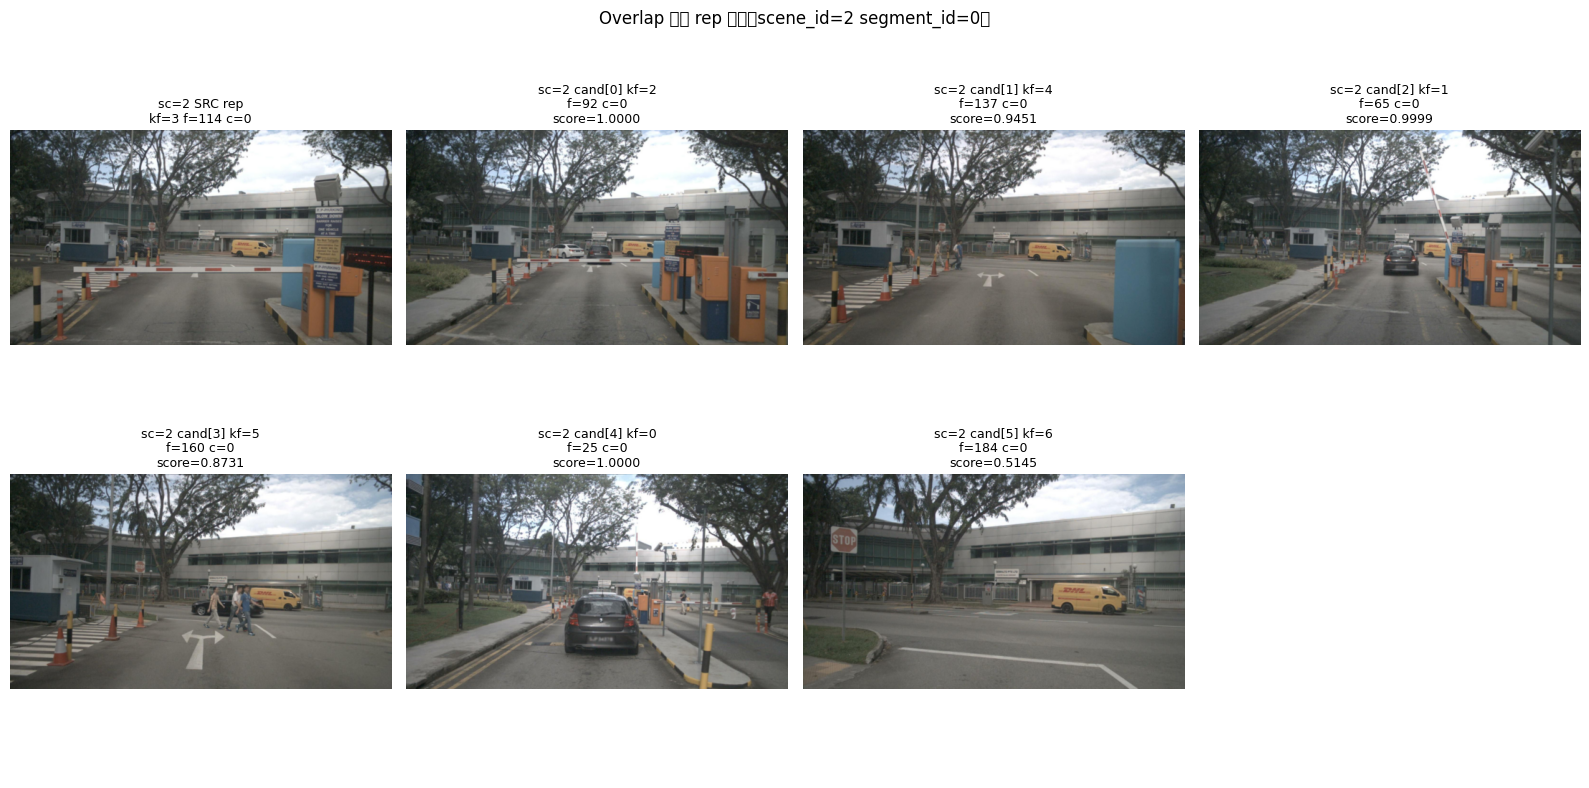

/tmp/ipykernel_70104/2004065542.py:159: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_70104/2004065542.py:159: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_70104/2004065542.py:159: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_70104/2004065542.py:159: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/miniconda3/envs/drivestudio-new/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/drivestudio-new/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) 

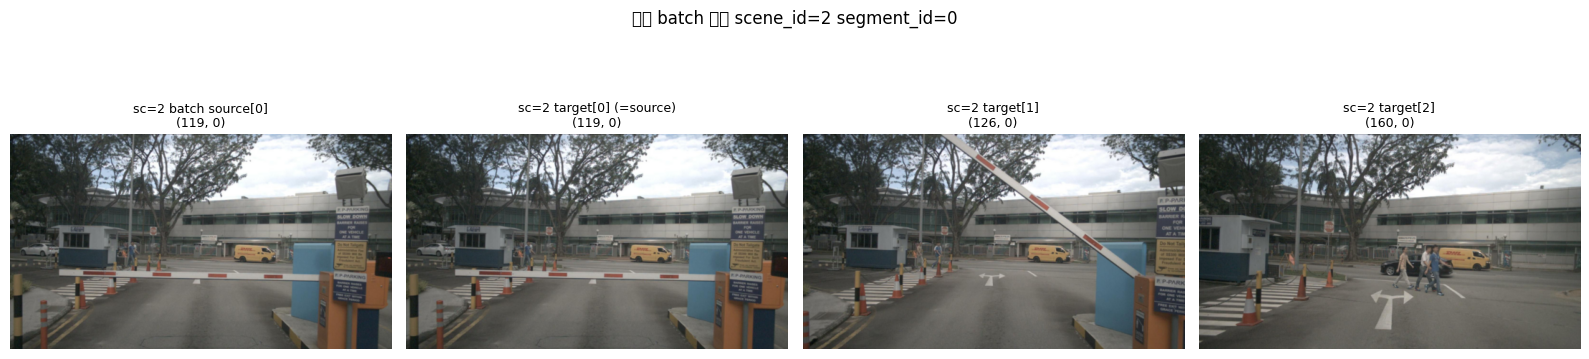


get_current_info: scene_id = 2 segment_id = 0
get_current_info: source_keyframe_idx = 3
get_current_info: source_image_ref = (119, 0)
get_current_info: target_image_refs = [(119, 0), (126, 0), (160, 0)]


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from omegaconf import OmegaConf

# 与 YAML scheduler_v4.overlap 对照
_ov = cfg_multi.scheduler_v4.overlap
print("scheduler_v4.overlap (config):", OmegaConf.to_container(_ov, resolve=True))

# 1) 持续 next_batch 直到本步 pop_events 含 overlap_select（pointcloud_topk 下在新 block 首步出现）
_MAX_STEPS_UNTIL_OVERLAP = 200_000
raw_batch = None
events: list = []
os_ev = None
bb_ev = None
for _step in range(_MAX_STEPS_UNTIL_OVERLAP):
    raw_batch = sch_multi.next_batch()
    events = sch_multi.pop_events()
    os_ev = next((e for e in events if e.get("type") == "overlap_select"), None)
    bb_ev = next((e for e in events if e.get("type") == "block_begin"), None)
    if os_ev is not None:
        print(f"[wait overlap_select] 经过 next_batch 步数: {_step + 1}")
        break
else:
    raise RuntimeError(
        f"{_MAX_STEPS_UNTIL_OVERLAP} 步内未出现 overlap_select。"
        "请确认 scheduler_v4.overlap.mode 为 pointcloud_topk；若为 none 则不会有该事件。"
    )

print("\n--- 本步 events 类型 ---", [e.get("type") for e in events])

assert os_ev is not None and raw_batch is not None
_sc = int(os_ev["scene_id"])
_seg = int(os_ev["segment_id"])
_kf_src = int(os_ev["source_keyframe_idx"])
print(
    f"\n--- 场景 / keyframe / frame（overlap_select）---\n"
    f"scene_id={_sc} segment_id={_seg}\n"
    f"source_keyframe_idx={_kf_src}  source_image_ref(train)={os_ev.get('source_image_ref')}  "
    f"source_rep_image_ref={os_ev.get('source_rep_image_ref')}"
)

print("\n--- overlap 候选（rep 帧用于 pointcloud_topk 打分；顺序与 candidate_scores 一致）---")
_cand_kfs = list(os_ev.get("candidate_keyframe_indices") or [])
_cand_scores = list(os_ev.get("candidate_scores") or [])
_cand_rep = list(os_ev.get("candidate_rep_image_refs") or [])
_cand_cnt = list(os_ev.get("candidate_pair_counts") or [])
_cand_tgt_lists = list(os_ev.get("candidate_target_image_ref_lists") or [])
for i, kf in enumerate(_cand_kfs):
    score = _cand_scores[i] if i < len(_cand_scores) else None
    rep = tuple(_cand_rep[i]) if i < len(_cand_rep) else None
    cnt = _cand_cnt[i] if i < len(_cand_cnt) else {}
    ntrain = len(_cand_tgt_lists[i]) if i < len(_cand_tgt_lists) else 0
    fr, cm = (int(rep[0]), int(rep[1])) if rep is not None else (-1, -1)
    print(
        f"  [{i}] scene_id={_sc} keyframe={kf}  rep_frame={fr} cam={cm}  "
        f"score={score}  n_a/n_b/n_ab={cnt}  train_frames_in_kf={ntrain}"
    )

print("\n--- 选中 extra target（训练帧）---")
print("selected_target_image_refs:", os_ev.get("selected_target_image_refs"))
print("selected_target_scores:", os_ev.get("selected_target_scores"))
print("overlap_mode:", os_ev.get("overlap_mode"))
print("overlap_score_type:", os_ev.get("overlap_score_type"))
print("overlap_point_sample_size:", os_ev.get("overlap_point_sample_size"))
print("extra_target_count:", os_ev.get("extra_target_count"))
print(
    "cache_hits / cache_misses:",
    os_ev.get("cache_hits"),
    os_ev.get("cache_misses"),
)
print(
    "pair_compute_miss_time_ms_total / pair_eval_wall_time_ms_total:",
    os_ev.get("pair_compute_miss_time_ms_total"),
    os_ev.get("pair_eval_wall_time_ms_total"),
)

if bb_ev is not None and bb_ev.get("selected_target_scores") is not None:
    print("\n--- block_begin.selected_target_scores ---")
    print(bb_ev.get("selected_target_scores"))


def _to_hwc_uint8(img_t: torch.Tensor) -> np.ndarray:
    x = img_t.detach().float().cpu()
    if x.dim() == 4:
        x = x[0]
    if x.dim() == 3 and x.shape[0] in (1, 3) and x.shape[-1] not in (1, 3):
        x = x.permute(1, 2, 0)
    a = x.numpy()
    a = np.clip(a, 0.0, 1.0)
    if a.shape[-1] == 1:
        a = np.repeat(a, 3, axis=-1)
    return (a * 255.0).astype(np.uint8)


def _image_from_ref(ref: tuple[int, int]) -> torch.Tensor:
    """按 (frame, cam) 从数据集取 RGB（走 view-pack cache 路径）。"""
    sd = ds_multi.get_scene(_sc)
    if sd is None:
        raise RuntimeError(f"get_scene({_sc}) returned None")
    pack = ds_multi._get_cached_or_load_view_from_image_ref(_sc, _seg, sd["dataset"], tuple(ref))
    return pack["image"]


# 2) 可视化：source rep + 每个候选 rep（同一 scene_id），标题含 keyframe / frame / score
_rep_src = tuple(int(x) for x in os_ev["source_rep_image_ref"])
_overlap_row: list[tuple[torch.Tensor, str]] = [
    (_image_from_ref(_rep_src), f"sc={_sc} SRC rep\nkf={_kf_src} f={_rep_src[0]} c={_rep_src[1]}"),
]
for i, kf in enumerate(_cand_kfs):
    rep = tuple(int(x) for x in _cand_rep[i])
    scv = _cand_scores[i] if i < len(_cand_scores) else float("nan")
    _overlap_row.append(
        (
            _image_from_ref(rep),
            f"sc={_sc} cand[{i}] kf={kf}\nf={rep[0]} c={rep[1]}\nscore={scv:.4f}",
        )
    )

_nov = len(_overlap_row)
_nc = min(4, max(1, _nov))
_nrows = int(np.ceil(_nov / _nc))
fig1, _ = plt.subplots(_nrows, _nc, figsize=(4 * _nc, 4 * _nrows))
for idx, ax in enumerate(fig1.axes):
    if idx < _nov:
        im, lab = _overlap_row[idx]
        ax.imshow(_to_hwc_uint8(im))
        ax.set_title(lab, fontsize=9)
    ax.axis("off")
fig1.suptitle(f"Overlap 候选 rep 图像（scene_id={_sc} segment_id={_seg}）", fontsize=12)
plt.tight_layout()
plt.show()

# 3) 当前 batch：训练用 source + 全部 target（含 target[0]==source）
info = sch_multi.get_current_info()
src_img = raw_batch["source"]["image"]
tgt_img = raw_batch["target"]["image"]
imgs2: list[torch.Tensor] = []
labels2: list[str] = []
trefs = list(info.get("target_image_refs") or [])
for i in range(int(src_img.shape[0])):
    imgs2.append(src_img[i])
    labels2.append(f"sc={_sc} batch source[{i}]\n{tuple(os_ev.get('source_image_ref') or ())}")
for j in range(int(tgt_img.shape[0])):
    imgs2.append(tgt_img[j])
    tr = trefs[j] if j < len(trefs) else None
    labels2.append(
        f"sc={_sc} target[{j}]" + (" (=source)" if j == 0 else "") + (f"\n{tr}" if tr is not None else "")
    )

fig2, axes2 = plt.subplots(1, len(imgs2), figsize=(4 * len(imgs2), 4.5))
if len(imgs2) == 1:
    axes2 = [axes2]
for ax, im, lab in zip(axes2, imgs2, labels2):
    ax.imshow(_to_hwc_uint8(im))
    ax.set_title(lab, fontsize=9)
    ax.axis("off")
fig2.suptitle(f"本步 batch 图像 scene_id={_sc} segment_id={_seg}", fontsize=12)
plt.tight_layout()
plt.show()

print("\nget_current_info: scene_id =", info.get("scene_id"), "segment_id =", info.get("segment_id"))
print("get_current_info: source_keyframe_idx =", info.get("source_keyframe_idx"))
print("get_current_info: source_image_ref =", info.get("source_image_ref"))
print("get_current_info: target_image_refs =", info.get("target_image_refs"))

In [6]:
MULTI_MAX_STEPS = 4000
# 设为 >1 可稀疏打印（例如 10 表示每 10 步一行）；1 表示每步都打印
PRINT_EVERY = 1
# 是否在每步打印本步 pop_events 的完整 payload（便于对照调度器）
PRINT_EVENT_PAYLOAD = True

scene_ids_seen: set[int] = set()
segment_begin_rows: list[tuple[int, int, int]] = []


def _fmt_event_one_line(ev: dict) -> str:
    t = ev.get("type")
    if t == "segment_begin":
        return (
            f"segment_begin gstep={ev.get('global_step')} sc={ev.get('scene_id')} seg={ev.get('segment_id')} "
            f"budget_u={ev.get('segment_budget_u')} step_budget={ev.get('segment_step_budget')} "
            f"U={ev.get('U')} updates_per_block={ev.get('updates_per_block')} "
            f"kf_ep={ev.get('keyframes_per_episode')} ep_seg={ev.get('episodes_per_segment')} "
            f"w_eff={ev.get('w_eff')} b_seg={ev.get('b_seg')}"
        )
    if t == "reset_event":
        return (
            f"reset_event gstep={ev.get('global_step')} sc={ev.get('scene_id')} seg={ev.get('segment_id')} "
            f"reset_episode_idx={ev.get('reset_episode_idx')} reason={ev.get('reason')} "
            f"window_kf={ev.get('window_keyframes')} num_pairs={ev.get('num_pairs')}"
        )
    if t == "block_begin":
        return (
            f"block_begin gstep={ev.get('global_step')} sc={ev.get('scene_id')} seg={ev.get('segment_id')} "
            f"blk_seg={ev.get('block_idx_in_segment')} blk_g={ev.get('block_idx_global')} "
            f"U={ev.get('U')} K_u_nom={ev.get('K_u_nominal')} K_u_eff={ev.get('K_u_effective')} "
            f"K_steps_eff={ev.get('K_steps_effective')} src_kf={ev.get('source_keyframe_idx')} "
            f"src_frame={ev.get('source_frame_idx')} src_cam={ev.get('source_cam_idx')} "
            f"src_ref={ev.get('source_image_ref')}"
        )
    if t == "block_end":
        return (
            f"block_end gstep={ev.get('global_step')} sc={ev.get('scene_id')} seg={ev.get('segment_id')} "
            f"blk_seg={ev.get('block_idx_in_segment')} blk_g={ev.get('block_idx_global')} "
            f"num_updates_in_block={ev.get('num_updates_in_block')} K_u_eff={ev.get('K_u_effective')} "
            f"src_ref={ev.get('source_image_ref')}"
        )
    if t == "preload_hint":
        return f"preload_hint gstep={ev.get('global_step')} sc={ev.get('scene_id')} seg={ev.get('segment_id')} scope={ev.get('hint_scope')}"
    if t == "segment_end":
        return (
            f"segment_end gstep={ev.get('global_step')} sc={ev.get('scene_id')} seg={ev.get('segment_id')} "
            f"segment_local_u={ev.get('segment_local_u')} src_ref={ev.get('source_image_ref')}"
        )
    return f"{t} gstep={ev.get('global_step')} keys={sorted(ev.keys())}"


print(
    "字段说明: raw = segment_local_step/segment_step_budget (本 segment 内 raw step); "
    "U域 = segment_local_u/segment_budget_u (update units); "
    "blk = block_idx_in_segment / block_idx_global; "
    "u_in_block / K_u_eff = 当前 block 内已消费 U 步数 / 本 block 有效长度(与 block_end 对齐)."
)
print("-" * 100)

for step in range(MULTI_MAX_STEPS):
    raw_batch = sch_multi.next_batch()
    info = sch_multi.get_current_info()
    events = sch_multi.pop_events()

    for ev in events:
        if ev.get("type") == "segment_begin":
            segment_begin_rows.append(
                (int(ev.get("global_step", -1)), int(ev.get("scene_id", -1)), int(ev.get("segment_id", -1)))
            )

    sid = int(info["scene_id"])
    segid = int(info["segment_id"])
    scene_ids_seen.add(sid)

    tgt = raw_batch.get("target")
    if not isinstance(tgt, dict) or tgt.get("image") is None:
        raise AssertionError("batch must contain target.image")

    st = getattr(sch_multi, "current_segment_state", None)
    u_ib = eff_ub = None
    if isinstance(st, dict):
        u_ib = st.get("u_in_block")
        eff_ub = st.get("effective_u_this_block")

    if step % PRINT_EVERY == 0:
        print(
            f"[loop {step:04d}] sched_global_step={info.get('global_step')} | "
            f"scene={sid} segment={segid} | "
            f"raw {info.get('segment_local_step')}/{info.get('segment_step_budget')} | "
            f"U域 {info.get('segment_local_u')}/{info.get('segment_budget_u')} | "
            f"blk_seg={info.get('block_idx_in_segment')} blk_g={info.get('block_idx_global')} | "
            f"u_in_block={u_ib}/{eff_ub} | "
            f"K_u_nom={info.get('K_u_nominal')} K_u_eff={info.get('K_u_effective')} U={info.get('U')} | "
            f"src_kf={info.get('source_keyframe_idx')} src_frame={info.get('source_frame_idx')} cam={info.get('source_cam_idx')} | "
            f"src_ref={info.get('source_image_ref')} | "
            f"targets_n={len(info.get('target_image_refs') or [])} | "
            f"target.image batch={tuple(tgt['image'].shape)}"
        )
        if events:
            for ev in events:
                if PRINT_EVENT_PAYLOAD:
                    print("    ev:", _fmt_event_one_line(ev))
                else:
                    print("    ev:", ev.get("type"))
        else:
            print("    ev: (none)")

else:
    print(
        "[multi] warning: only one scene_id in get_current_info within",
        MULTI_MAX_STEPS,
        "steps; seen:",
        scene_ids_seen,
    )

print("-" * 100)
print("[multi] distinct scene_ids (from info):", sorted(scene_ids_seen))
print("[multi] segment_begin count:", len(segment_begin_rows))
print("[multi] segment_begin (global_step, scene_id, segment_id):", segment_begin_rows[:16])
if len(scene_ids_seen) >= 2:
    print("[multi] OK: observed multiple scenes in the loop.")
else:
    print("[multi] Only one scene observed; increase MULTI_MAX_STEPS or check nuScenes scenes in train_scene_ids.")

字段说明: raw = segment_local_step/segment_step_budget (本 segment 内 raw step); U域 = segment_local_u/segment_budget_u (update units); blk = block_idx_in_segment / block_idx_global; u_in_block / K_u_eff = 当前 block 内已消费 U 步数 / 本 block 有效长度(与 block_end 对齐).
----------------------------------------------------------------------------------------------------
[loop 0000] sched_global_step=2 | scene=2 segment=0 | raw 2/336 | U域 0/112 | blk_seg=0 blk_g=1 | u_in_block=0/8 | K_u_nom=8 K_u_eff=8 U=3 | src_kf=3 src_frame=119 cam=0 | src_ref=(119, 0) | targets_n=3 | target.image batch=(3, 300, 533, 3)
    ev: (none)
[loop 0001] sched_global_step=3 | scene=2 segment=0 | raw 3/336 | U域 1/112 | blk_seg=0 blk_g=1 | u_in_block=1/8 | K_u_nom=8 K_u_eff=8 U=3 | src_kf=3 src_frame=119 cam=0 | src_ref=(119, 0) | targets_n=3 | target.image batch=(3, 300, 533, 3)
    ev: (none)
[loop 0002] sched_global_step=4 | scene=2 segment=0 | raw 4/336 | U域 1/112 | blk_seg=0 blk_g=1 | u_in_block=1/8 | K_u_nom=8 K_u_eff=8 U=3 |

KeyboardInterrupt: 

## 6. 清理

In [ ]:
ds_multi.shutdown_preload()
print("shutdown_preload done (ds_multi)")